# Guided 6: Fine-tuning Large Language Model (LLM)

Dalam lab ini, Anda akan melakukan fine-tuning pada large language model (LLM) dengan miliaran parameter. Kita akan membahas beberapa konsep dasar LLM, termasuk tokenisasi, template, dan fine-tuning. Lab ini menyediakan pipeline lengkap untuk melakukan fine-tuning model bahasa agar menghasilkan respons dengan gaya tertentu, dan Anda tidak hanya akan mengeksplorasi fine-tuning model bahasa, tetapi juga cara mengevaluasi performa model bahasa.

Anda akan menggunakan model [Gemma 2B](https://huggingface.co/google/gemma-2b-it) dari Google sebagai model bahasa dasar untuk di-fine-tune; [LFM-40B](https://www.liquid.ai/liquid-foundation-models) dari [Liquid AI](https://www.liquid.ai/) sebagai model "juri" evaluasi; dan [Opik](https://www.comet.com/site/products/opik/) dari Comet ML sebagai kerangka kerja untuk evaluasi LLM yang efisien.

Pertama, mari unduh paket deep learning MIT, instal dependensi, dan impor paket relevan yang akan kita butuhkan untuk lab ini.

In [1]:
# # Install and import MIT Deep Learning utilities
# !pip install openai datasets torch opencv-python transformers
!pip install mitdeeplearning > /dev/null 2>&1
import mitdeeplearning as mdl

2025-12-02 10:37:31.339817: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 10:37:31.370493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764646651.406637 2221224 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764646651.418552 2221224 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-02 10:37:31.459353: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from lion_pytorch import Lion

# Bagian 1: Fine-tuning LLM untuk gaya

Pada bagian pertama lab ini, kita akan melakukan fine-tuning LLM sebagai chatbot yang dapat menghasilkan respons dengan gaya tertentu. Kita akan menggunakan [model Gemma 2B](https://huggingface.co/google/gemma-2b-it) sebagai model bahasa dasar untuk di-finetune.

## 1.1: Templating dan tokenisasi

### 1.1.1: Templating

Model bahasa yang berfungsi sebagai chatbot mampu menghasilkan respons terhadap kueri pengguna -- tetapi bagaimana mereka melakukannya? Kita perlu memberi mereka cara untuk memahami percakapan dan menghasilkan respons dengan cara yang koheren -- semacam struktur mengenai apa itu input dan output.

[Templating](https://huggingface.co/docs/transformers/main/chat_templating) adalah cara untuk memformat input dan output dalam struktur konsisten yang dapat dipahami oleh model bahasa. Ini melibatkan penambahan token atau penanda khusus untuk menunjukkan bagian-bagian berbeda dari percakapan, seperti siapa yang berbicara dan di mana giliran dimulai dan berakhir. Struktur ini membantu model mempelajari format yang tepat untuk menghasilkan respons dan mempertahankan alur percakapan yang koheren. Tanpa template, model mungkin tidak tahu cara memformat outputnya dengan benar atau membedakan antara pembicara yang berbeda dalam percakapan.

Mari kita mulai dengan mendefinisikan beberapa template dasar untuk chatbot, khususnya untuk giliran di mana pengguna mengajukan pertanyaan dan model merespons dengan jawaban.

In [3]:
# Template tanya-jawab dasar
template_without_answer = "<start_of_turn>user\n{question}<end_of_turn>\n<start_of_turn>model\n"
# Penjelasan:
# - String ini menyiapkan struktur prompt agar model mengerti giliran bicara.
# - {question} adalah placeholder (tempat penampung) yang nanti akan diganti dengan pertanyaan asli.
# - \n adalah karakter "newline" (pindah baris/enter).
# - <start_of_turn> dan <end_of_turn> adalah token khusus agar model tahu kapan user mulai/selesai bicara.

template_with_answer = template_without_answer + "{answer}<end_of_turn>\n"
# Penjelasan:
# - Baris ini menggabungkan (concatenate) string template pertanyaan di atas dengan bagian jawaban.
# - {answer} adalah placeholder untuk jawaban yang diharapkan dari model.

# Mari kita coba masukkan sesuatu ke dalam template untuk melihat bagaimana bentuknya
print(template_with_answer.format(question="What is your name?", answer="My name is Gemma!"))
# Penjelasan:
# - .format(...) adalah metode string Python untuk mengisi placeholder.
# - question="..." akan menggantikan {question}
# - answer="..." akan menggantikan {answer}

<start_of_turn>user
What is your name?<end_of_turn>
<start_of_turn>model
My name is Gemma!<end_of_turn>



### 1.1.2: Tokenisasi

Untuk memproses bahasa, kita perlu mempersiapkan teks bagi model. Pada dasarnya, kita bisa menganggap bahasa sebagai urutan "potongan" teks. Kita bisa memecah teks menjadi potongan-potongan individu, lalu memetakan potongan ini ke token numerik -- secara kolektif ini adalah proses [tokenisasi](https://huggingface.co/docs/transformers/main/tokenizer_summary). Token numerik kemudian dapat dimasukkan ke dalam model bahasa.

Ada beberapa pendekatan umum untuk menokenisasi teks bahasa alami:

1. **Tokenisasi berbasis kata**: memecah teks menjadi kata-kata individu. Meskipun sederhana, ini dapat menyebabkan kosakata (vocabulary) yang besar dan tidak menangani kata-kata yang tidak dikenal dengan baik.

2. **Tokenisasi berbasis karakter**: memecah teks menjadi karakter individu. Meskipun ini melibatkan kosakata yang sangat kecil, ini menghasilkan urutan yang panjang dan kehilangan makna tingkat kata.

3. **Tokenisasi subkata**: memecah kata menjadi unit yang lebih kecil (subkata) berdasarkan frekuensinya. Pendekatan yang paling populer dan umum digunakan adalah [byte-pair encoding (BPE)](https://en.wikipedia.org/wiki/Byte_pair_encoding), yang secara iteratif menggabungkan pasangan karakter yang paling sering muncul. Model bahasa modern biasanya menggunakan tokenisasi subkata karena menyeimbangkan ukuran kosakata dan panjang urutan sambil menangani kata-kata yang tidak dikenal secara efektif dengan memecahnya menjadi unit subkata yang dikenal.

Dalam lab ini kita akan menggunakan tokenizer dari model Gemma 2B, yang menggunakan BPE. Mari kita muat dan periksa.

In [4]:
# Memuat tokenizer untuk Gemma 2B
model_id = "unsloth/gemma-2-2b-it" #"google/gemma-2-2b-it"
# Penjelasan:
# - Kita mendefinisikan ID model yang ada di Hugging Face.
# - Versi "unsloth/..." digunakan di sini karena pustaka Unsloth mengoptimalkan model agar fine-tuning lebih cepat dan hemat memori.

tokenizer = AutoTokenizer.from_pretrained(model_id)
# Penjelasan:
# - AutoTokenizer adalah kelas utilitas yang secara otomatis mendeteksi jenis tokenizer yang tepat berdasarkan string 'model_id'.
# - .from_pretrained() mengunduh konfigurasi dan file kosakata (vocabulary) dari cloud (atau cache lokal).

# Seberapa besar tokenizer-nya?
print(f"Vocab size: {len(tokenizer.get_vocab())}")
# Penjelasan:
# - .get_vocab() mengembalikan dictionary berisi semua token yang dikenali model.
# - len(...) menghitung jumlah total token tersebut (ukuran kosakata).

Vocab size: 256000


Kita tidak hanya perlu mampu menokenisasi teks menjadi token (encode), tetapi juga men-detokenisasi token kembali menjadi teks (decode). Tokenizer kita akan memiliki:
1. fungsi `encode` untuk menokenisasi teks menjadi token, dan
2. fungsi `decode` untuk men-detokenisasi kembali menjadi teks agar kita bisa membaca output model.



Mari kita uji kedua langkah tersebut dan periksa untuk mendapatkan pemahaman yang lebih baik tentang cara kerjanya.

In [5]:
# Mari kita uji kedua langkah tersebut:
text = "Here is some sample text!"
print(f"Original text: {text}")

# Menokenisasi teks (Encode: Teks -> Angka)
tokens = tokenizer.encode(text, return_tensors="pt")
print(f"Encoded tokens: {tokens}")
# Penjelasan:
# - .encode() mengubah string menjadi urutan angka (token IDs).
# - return_tensors="pt" sangat penting: ini memberitahu tokenizer untuk mengembalikan hasilnya dalam bentuk PyTorch Tensor, bukan list Python biasa. Ini format yang dibutuhkan model untuk memproses data.

# Men-decode token (Decode: Angka -> Teks)
decoded_text = tokenizer.decode(tokens[0], skip_special_tokens=True)
print(f"Decoded text: {decoded_text}")
# Penjelasan:
# - .decode() mengubah urutan angka kembali menjadi string.
# - tokens[0] digunakan karena hasil encode sebelumnya berbentuk batch 2 dimensi (contoh: [[1, 2, 3]]), jadi kita ambil urutan pertama.
# - skip_special_tokens=True membersihkan output dari token teknis seperti <bos> (beginning of sentence) atau <eos>, agar teks yang terbaca bersih.

Original text: Here is some sample text!
Encoded tokens: tensor([[     2,   4858,    603,   1009,   6453,   2793, 235341]])
Decoded text: Here is some sample text!


Ini sangat keren. Sekarang kita memiliki cara untuk masuk dan keluar dari ruang token.

Untuk "mengobrol" dengan chatbot LLM kita, kita perlu menggunakan tokenizer dan template obrolan secara bersamaan, agar model dapat merespons pertanyaan pengguna. Kita dapat menggunakan template yang didefinisikan sebelumnya untuk menyusun prompt bagi model, tanpa jawabannya.

In [6]:
prompt = template_without_answer.format(question="What is the capital of France? Use one word.")
# Penjelasan:
# - Kita menggunakan variabel `template_without_answer` yang sudah didefinisikan sebelumnya (yang berisi tag <start_of_turn>user...).
# - .format(...) bertugas mengisi placeholder `{question}` di dalam template tersebut dengan pertanyaan kita.
# - Sekarang variabel `prompt` berisi struktur lengkap yang siap dibaca oleh model (konteks user sudah ditutup, konteks model dibuka).

print(prompt)

<start_of_turn>user
What is the capital of France? Use one word.<end_of_turn>
<start_of_turn>model



Jika kita memasukkan ini ke model, ia akan melihat bahwa sekarang adalah awal dari giliran model, dan ia akan menghasilkan jawaban untuk pertanyaan ini.

## 1.2: Memulai dengan LLM

Sekarang setelah kita memiliki cara untuk mempersiapkan data kita, kita siap bekerja dengan LLM kita!

LLM seperti Gemma 2B dilatih pada korpus teks yang besar, dengan tugas memprediksi token berikutnya dalam suatu urutan, berdasarkan token-token sebelumnya. Kami menyebut tugas pelatihan ini "prediksi token berikutnya" (*next token prediction*); Anda mungkin juga melihatnya disebut sebagai "pemodelan bahasa kausal" (*causal language modeling*) atau "pemodelan bahasa autoregresif" (*autoregressive language modeling*). Kita dapat memanfaatkan model yang dilatih dengan cara ini untuk menghasilkan teks baru dengan mengambil sampel dari distribusi probabilitas yang diprediksi untuk token berikutnya.



Mari kita muat model Gemma 2B dan mulai bekerja dengannya. Kita akan menyusun prompt dalam bentuk template obrolan dan menokenisasinya. Kemudian, kita akan memasukkannya ke model untuk memprediksi probabilitas token berikutnya. Terakhir, kita akan mengambil token berikutnya (yang masih berupa angka) dan men-decode-nya menjadi teks.

In [11]:
# Memuat model -- perhatikan bahwa ini mungkin memakan waktu beberapa menit
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
# Penjelasan:
# - AutoModelForCausalLM: Kelas khusus dari Hugging Face yang dirancang untuk tugas Causal Language Modeling (generasi teks).
# - device_map="auto": Parameter penting yang secara otomatis mendistribusikan layer model ke perangkat keras yang tersedia (GPU, CPU, atau Hard Drive) secara optimal.
# Ini mencegah error 'Out of Memory' jika model terlalu besar untuk satu GPU.

In [37]:
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map={"": "cuda:0"}
)

### Menggabungkan semuanya untuk mem-prompt model dan menghasilkan respons ###

# 1. Menyusun prompt dalam bentuk template obrolan
question = "What is the capital of France? Use one word."
prompt = template_without_answer.format(question=question) # TODO

# 2. Menokenisasi prompt
tokens = tokenizer.encode(prompt, return_tensors="pt").to("cuda:0")
# Penjelasan:
# - .to(model.device): Sangat penting! Ini memindahkan data token ke perangkat keras yang sama dengan model (misalnya GPU). Jika model di GPU tapi data di CPU, akan terjadi error.

# 3. Masukkan ke dalam model untuk memprediksi probabilitas token berikutnya
with torch.no_grad():
# Penjelasan: torch.no_grad() memberitahu PyTorch untuk tidak menghitung gradien. Ini menghemat memori dan mempercepat proses karena kita sedang melakukan prediksi (inference), bukan pelatihan (training).
    output = model(input_ids=tokens) # TODO

    probs = F.softmax(output.logits, dim=-1)
    # Penjelasan:
    # - output.logits: Keluaran mentah model berupa skor numerik (belum berupa 0-100%).
    # - F.softmax(..., dim=-1): Mengubah skor mentah tersebut menjadi probabilitas (antara 0 dan 1). 'dim=-1' berarti operasi dilakukan pada dimensi kosakata terakhir.

# 4. Ambil token berikutnya, berdasarkan probabilitas maksimum
next_token = torch.argmax(probs[0, -1, :]).item()
# Penjelasan:
# - probs[0, -1, :]: Kita mengambil batch ke-0 (pertama), dan posisi token ke -1 (terakhir/terbaru). Kita ingin tahu apa kelanjutan dari kalimat tersebut.
# - torch.argmax: Fungsi ini mencari ID token mana yang memiliki nilai probabilitas TERTINGGI (paling mungkin muncul).
# - .item(): Mengubah format data dari Tensor PyTorch menjadi angka Python biasa (integer).

# 5. Decode token berikutnya
next_token_text = tokenizer.decode([next_token]) # TODO
# Penjelasan: Mengubah ID token (angka) yang dipilih tadi kembali menjadi karakter/kata agar bisa kita baca.

print(f"Prompt: {prompt}")
print(f"Predicted next token: {next_token_text}")

Prompt: <start_of_turn>user
What is the capital of France? Use one word.<end_of_turn>
<start_of_turn>model

Predicted next token: Paris


Perlu dicatat bahwa model tidak dapat memprediksi jawaban atas pertanyaan secara langsung, model hanya mampu memprediksi token berikutnya dalam urutan! Untuk pertanyaan yang lebih kompleks, kita tidak bisa hanya menghasilkan satu token, melainkan kita perlu menghasilkan urutan token.

Hal ini dapat dilakukan dengan melakukan proses di atas secara berulang (iteratif), langkah demi langkah -- setelah setiap langkah kita memasukkan token yang dihasilkan kembali ke dalam model dan memprediksi token berikutnya lagi.



Daripada melakukan ini secara manual sendiri, kita dapat menggunakan fungsionalitas bawaan model [`model.generate()`](https://huggingface.co/docs/transformers/main/en/main_classes/text_generation#transformers.GenerationMixin.generate) (didukung oleh pustaka Transformers HuggingFace) untuk menghasilkan sejumlah `max_new_tokens` token, dan men-decode output kembali menjadi teks.

In [38]:
prompt = template_without_answer.format(question="What does MIT stand for?")

# Encode prompt dan pindahkan ke device (GPU/CPU) yang sama dengan model
tokens = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

# Generate output secara otomatis
output = model.generate(tokens, max_new_tokens=20)
# Penjelasan:
# - model.generate(): Fungsi sakti ini melakukan loop "prediksi token -> ambil token -> masukkan balik ke input -> prediksi lagi" secara otomatis di belakang layar. Kita tidak perlu menulis loop manual seperti sebelumnya.
# - max_new_tokens=20: Membatasi model untuk hanya menghasilkan maksimal 20 token baru (mencegah model mengoceh terlalu panjang atau looping selamanya).

print(tokenizer.decode(output[0]))
# Penjelasan:
# - Output dari .generate() berisi gabungan lengkap: [Token Input Asli + Token Baru yang Dihasilkan].
# - decode() mengubah seluruh urutan angka tersebut menjadi kalimat utuh yang bisa dibaca.

<bos><start_of_turn>user
What does MIT stand for?<end_of_turn>
<start_of_turn>model
MIT stands for **Massachusetts Institute of Technology**. 
<end_of_turn>


Sekarang kita memiliki pipeline dasar untuk menghasilkan teks dengan LLM!

## 1.3: Fine-tuning

Fine-tuning adalah teknik yang memungkinkan kita mengadaptasi jaringan saraf yang telah dilatih sebelumnya (pre-trained) agar lebih sesuai dengan tugas hilir (downstream task), domain, atau gaya tertentu, dengan melatih model lebih lanjut pada data baru. Dengan melatih model lebih lanjut pada dataset yang dikurasi dengan cermat, kita dapat memodifikasi perilaku, gaya, atau kemampuannya. Fine-tuning digunakan dalam berbagai aplikasi, bukan hanya pemodelan bahasa. Namun dalam pemodelan bahasa, fine-tuning dapat digunakan untuk:
- Mengadaptasi gaya penulisan model
- Meningkatkan performa pada tugas atau domain tertentu
- Mengajarkan model kemampuan atau pengetahuan baru
- Mengurangi perilaku atau bias yang tidak diinginkan



Dalam lab ini, Anda akan melakukan fine-tuning pada LLM Gemma untuk mengadaptasi gaya penulisan model. Ingat kembali bahwa di Lab 1 Anda membangun model urutan berbasis RNN untuk menghasilkan lagu rakyat Irlandia. Melanjutkan tema Irlandia kita, pertama-tama kita akan melakukan fine-tuning LLM untuk mengobrol dengan gaya leprechaun.

![Let's Dance!](http://33.media.tumblr.com/3d223954ad0a77f4e98a7b87136aa395/tumblr_nlct5lFVbF1qhu7oio1_500.gif)

Kami telah menyiapkan dataset tanya-jawab di mana pertanyaannya dalam gaya bahasa Inggris standar (yaitu gaya "dasar") dan jawabannya dalam gaya "leprechaun" (ditulis oleh LLM lain). Mari kita muat dataset dan memeriksanya.

In [39]:
import mitdeeplearning as mdl

In [40]:
# Membuat data loader untuk pelatihan (train) dan pengujian (test)
train_loader, test_loader = mdl.lab3.create_dataloader(style="leprechaun")
# Penjelasan:
# - Fungsi ini memuat dataset khusus yang sudah disiapkan di library 'mdl'.
# - Argument `style="leprechaun"` memberitahu fungsi untuk mengambil dataset pasangan tanya-jawab dengan gaya bicara Leprechaun.
# - Loader ini nantinya akan memberi makan data ke model secara bertahap (batch) saat training.

# Mengambil satu contoh sampel data untuk diinspeksi
sample = train_loader.dataset[44]
# Penjelasan:
# - Kita mengakses `dataset` yang ada di dalam loader, lalu mengambil item pada indeks ke-44 secara acak.
# - Tujuannya hanya untuk melihat seperti apa bentuk datanya sebelum kita latih.

# Mengekstrak komponen data dari sampel
question = sample['instruction']    # Pertanyaan/Input pengguna
answer = sample['response']         # Jawaban target (gaya leprechaun)
answer_style = sample['response_style'] # Label gaya (metadata)

# Menampilkan data ke layar
print(f"Question: {question}\n\n" +
      f"Original Answer: {answer}\n\n" +
      f"Answer Style: {answer_style}")
# Penjelasan:
# - f-string digunakan untuk menggabungkan variabel ke dalam teks.
# - \n\n memberikan jarak dua baris agar output lebih rapi saat dibaca.

Question: Are lilies safe for cats?

Original Answer: No, lilies are toxic to cats if consumed and should not be kept in a household with cats

Answer Style: Och, no indeed, me hearty! Them lilies there be as dangerous as a pot o' gold guarded by a banshee to a wee kitty cat! If a whiskered lad or lass takes a bite of one, it's as bad as swallowing a curse from the old Hag herself. So, ye best keep them far from yer feline friends, or else ye'll be needin' more than just a four-leaf clover to bring luck back into yer home!


### 1.3.1: Fungsi obrolan

Sebelum kita memulai fine-tuning, kita akan membuat fungsi untuk mengobrol dengan model secara mudah, baik agar kita dapat memantau kemajuannya selama proses fine-tuning maupun untuk menghasilkan jawaban atas pertanyaan.

Ingat kembali langkah-langkah inti kita sebelumnya:
1. Susun prompt pertanyaan menggunakan template
2. Tokenisasi teks
3. Masukkan token melalui model untuk memprediksi probabilitas token berikutnya
4. Decode token yang diprediksi kembali menjadi teks

Gunakan langkah-langkah ini untuk membangun fungsi `chat` di bawah ini.

In [41]:
def chat(question, max_new_tokens=32, temperature=0.7, only_answer=False):
    # 1. Menyusun prompt menggunakan template
    prompt = template_without_answer.format(question=question) # TODO

    # 2. Menokenisasi teks
    input_ids = tokenizer(prompt, return_tensors="pt").to(model.device) # TODO
    # Penjelasan:
    # - Berbeda dengan .encode() sebelumnya, memanggil `tokenizer()` secara langsung menghasilkan dictionary yang berisi 'input_ids' dan 'attention_mask'.
    # - Ini format yang lebih lengkap dan disukai oleh model.generate().

    # 3. Masukkan ke model untuk memprediksi/generate token berikutnya
    with torch.no_grad():
        outputs = model.generate(**input_ids, do_sample=True, max_new_tokens=max_new_tokens, temperature=temperature) # TODO
        # Penjelasan:
        # - **input_ids: Membongkar (unpack) dictionary tadi agar argumennya masuk ke fungsi generate satu per satu.
        # - do_sample=True: Mengaktifkan pengambilan sampel acak (bukan cuma mengambil yang paling mungkin), membuat jawaban lebih bervariasi.
        # - temperature: Mengontrol "kreativitas". Nilai rendah = kaku/repetitif, Nilai tinggi = kreatif/acak.

    # 4. Hanya kembalikan jawaban jika only_answer bernilai True
    output_tokens = outputs[0]
    if only_answer:
        output_tokens = output_tokens[input_ids['input_ids'].shape[1]:]
        # Penjelasan Teknis:
        # - model.generate() mengembalikan [Prompt Asli + Jawaban Baru].
        # - Baris ini menghitung panjang prompt asli (input_ids.shape[1]), lalu memotong (slice) output sehingga yang tersisa hanya bagian jawaban baru.

    # 5. Decode token kembali menjadi teks
    result = tokenizer.decode(output_tokens, skip_special_tokens=True) # TODO

    return result

Mari kita coba mengobrol dengan model sekarang untuk menguji apakah itu berhasil! Kita punya contoh pertanyaan di sini (melanjutkan tema Irlandia); jangan ragu untuk mencoba pertanyaan lain!

In [42]:
# Mari kita coba mengobrol dengan model sekarang untuk menguji apakah berhasil!
answer = chat(
    "What is the capital of Ireland?",
    only_answer=True,
    max_new_tokens=32,
)

print(answer)

'''TODO: Bereksperimenlah dengan mengajukan pertanyaan berbeda dan nilai temperature yang berbeda pada model, dan lihat bagaimana responnya!'''

The capital of Ireland is **Dublin**. 



'TODO: Bereksperimenlah dengan mengajukan pertanyaan berbeda dan nilai temperature yang berbeda pada model, dan lihat bagaimana responnya!'

### 1.3.2: Fine-tuning yang efisien parameter

Dalam fine-tuning, bobot model diperbarui agar lebih sesuai dengan dataset dan/atau tugas fine-tuning. Memperbarui semua bobot dalam model bahasa seperti Gemma 2B -- yang memiliki ~2 miliar parameter -- sangat mahal secara komputasi. Ada banyak teknik untuk membuat fine-tuning menjadi lebih efisien.

Kami akan menggunakan teknik yang disebut [LoRA](https://arxiv.org/abs/2106.09685) -- *low-rank adaptation* (adaptasi rank rendah) -- untuk membuat proses fine-tuning lebih efisien. LoRA adalah cara untuk melakukan fine-tuning LLM dengan sangat efisien dengan hanya memperbarui sebagian kecil parameter model, dan cara kerjanya adalah dengan menambahkan matriks rank rendah yang dapat dilatih ke dalam model. Meskipun kita tidak akan membahas detail LoRA di sini, Anda dapat membaca lebih lanjut di [makalah LoRA](https://arxiv.org/abs/2106.09685). Kita akan menggunakan pustaka [`peft`](https://pypi.org/project/peft/) untuk menerapkan LoRA pada model Gemma.



[Image of LoRA architecture diagram]

In [43]:
# LoRA adalah cara untuk mem-finetune LLM dengan sangat efisien dengan hanya memperbarui sebagian kecil parameter model

def apply_lora(model):
    # Mendefinisikan konfigurasi LoRA
    lora_config = LoraConfig(
        r=8, # rank dari matriks LoRA
        # Penjelasan: 'r' menentukan ukuran matriks adaptasi. Semakin kecil 'r', semakin sedikit parameter yang dilatih, tapi kapasitas belajar lebih rendah.
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj"
        ],
        # Penjelasan: 'target_modules' adalah daftar layer spesifik dalam arsitektur Transformer (seperti Query, Key, Value projection) yang akan "ditempeli" adaptor LoRA.
    )

    # Menerapkan LoRA ke model
    lora_model = get_peft_model(model, lora_config)
    # Penjelasan: Fungsi ini membungkus model asli. Model asli dibekukan (frozen/tidak bisa diedit), dan hanya layer LoRA tambahan yang disiapkan untuk dilatih.
    return lora_model

model = apply_lora(model)

# Mencetak jumlah parameter yang dapat dilatih setelah menerapkan LoRA
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"number of trainable parameters: {trainable_params}")
print(f"total parameters: {total_params}")
print(f"percentage of trainable parameters: {trainable_params / total_params * 100:.2f}%")
# Penjelasan:
# - Kode ini menghitung rasio efisiensi.
# - Biasanya dengan LoRA, kita akan melihat bahwa kita hanya melatih kurang dari 1% (misalnya 0.3% - 1%) dari total parameter, yang sangat menghemat memori GPU.

number of trainable parameters: 10383360
total parameters: 2624725248
percentage of trainable parameters: 0.40%


### 1.3.3: Forward pass dan perhitungan loss

Sekarang mari kita definisikan fungsi untuk melakukan *forward pass* melalui LLM dan menghitung *loss* (kerugian/kesalahan). *Forward pass* memberi kita *logits* -- yang mencerminkan distribusi probabilitas untuk token berikutnya. Kita dapat menghitung *loss* dengan membandingkan *logits* yang diprediksi dengan token berikutnya yang sebenarnya -- label target kita. Perhatikan bahwa ini sebenarnya adalah masalah klasifikasi! Jadi, *loss* kita dapat ditangkap oleh *cross entropy loss*, dan kita dapat menggunakan fungsi [`nn.functional.cross_entropy`](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html) dari PyTorch untuk menghitungnya.

In [44]:
def forward_and_compute_loss(model, tokens, mask, context_length=512):
    # Potong (truncate) sesuai panjang konteks
    tokens = tokens[:, :context_length]
    mask = mask[:, :context_length]

    # Menyusun input, output, dan masker
    x = tokens[:, :-1]
    y = tokens[:, 1:]
    mask = mask[:, 1:]
    # Penjelasan Penting:
    # - x (Input): Mengambil semua token KECUALI yang terakhir.
    # - y (Target): Mengambil semua token KECUALI yang pertama.
    # - Kenapa? Karena untuk memprediksi token di posisi i, kita menggunakan token 0 sampai i-1.
    #   Contoh: Kalimat "Saya suka kopi".
    #   Input (x): "Saya", "suka"
    #   Target (y): "suka", "kopi"
    #   Model dilatih: Saat melihat "Saya", harus prediksi "suka". Saat lihat "Saya suka", harus prediksi "kopi".

    # Forward pass untuk menghitung logits
    logits = model(x).logits
    # Penjelasan: Model memproses 'x' dan mengeluarkan skor mentah (logits) untuk setiap kemungkinan kata berikutnya.

    # Hitung loss
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        y.view(-1),
        reduction="none"
    )
    # Penjelasan:
    # - .view(-1, ...): Meratakan (flatten) batch dan sequence menjadi satu baris panjang agar bisa dihitung oleh fungsi loss.
    # - reduction="none": Kita tidak langsung merata-rata (mean) loss-nya di sini, karena kita perlu membuang loss pada bagian masking dulu.

    # Masking loss untuk token yang bukan jawaban
    loss = loss[mask.view(-1)].mean()
    # Penjelasan:
    # - Dalam fine-tuning instruksi, kita biasanya hanya ingin menghitung error pada JAWABAN model, bukan pada PERTANYAAN user.
    # - Mask ini menyaring agar loss hanya dihitung pada token yang relevan.

    return loss

### 1.3.4: Loop pelatihan untuk fine-tuning

Dengan fungsi untuk menghitung loss ini, kita sekarang dapat mendefinisikan loop pelatihan untuk melakukan fine-tuning model menggunakan LoRA. Loop pelatihan ini memiliki komponen inti yang sama seperti yang telah kita lihat sebelumnya di lab lain:
1. Ambil satu batch data dari dataset (menggunakan DataLoader)
2. Masukkan data melalui model untuk menyelesaikan *forward pass* dan menghitung *loss*
3. *Backward pass* untuk memperbarui bobot model

Data dalam DataLoader kita awalnya berupa teks, dan belum terstruktur dalam template tanya-jawab kita. Jadi pada langkah (1) kita perlu memformat data ke dalam template tanya-jawab yang telah didefinisikan sebelumnya, lalu menokenisasi teks tersebut.

Kita peduli dengan jawaban model terhadap pertanyaan; token "jawaban" adalah bagian dari teks yang ingin kita prediksi dan hitung *loss*-nya. Jadi, setelah menokenisasi teks, kita perlu menandai pada model token mana yang merupakan bagian dari "jawaban" dan mana yang merupakan bagian dari "pertanyaan". Kita dapat melakukan ini dengan menghitung *mask* (topeng) untuk token jawaban, dan kemudian menggunakan *mask* ini untuk menghitung *loss*.



Terakhir, kita akan menyelesaikan *backward pass* untuk memperbarui bobot model.

Mari kita gabungkan semua ini dalam loop pelatihan di bawah ini.

In [45]:
### Training loop ###

def train(model, dataloader, tokenizer, max_steps=200, context_length=512, learning_rate=1e-4):
    losses = []

    # Terapkan LoRA ke model
    model = apply_lora(model) # TODO
    # Penjelasan: Memanggil fungsi yang kita buat di 1.3.2 untuk menyuntikkan adapter LoRA ke model beku.

    optimizer = Lion(model.parameters(), lr=learning_rate)
    # Penjelasan:
    # - Lion adalah algoritma optimizer modern (alternatif dari AdamW) yang sering digunakan untuk LLM karena efisiensi memori dan performanya.
    # - lr (learning rate) menentukan seberapa besar langkah perubahan bobot setiap kali update.

    # Loop Pelatihan
    for step, batch in enumerate(dataloader):
        question = batch["instruction"][0]
        answer = batch["response_style"][0]
        # Catatan: Di sini kode mengambil 'response_style' sebagai jawaban.
        # Pastikan kolom ini benar-benar berisi TEKS jawaban yang diinginkan (gaya leprechaun), bukan sekadar label "leprechaun".

        # Format pertanyaan dan jawaban ke dalam template
        text = template_with_answer.format(question=question, answer=answer) # TODO

        # Tokenisasi teks dan hitung mask untuk jawaban
        ids = tokenizer(text, return_tensors="pt", return_offsets_mapping=True).to(model.device)
        # Penjelasan:
        # - return_offsets_mapping=True: Ini fitur canggih. Selain token ID, tokenizer juga memberikan info posisi karakter (start, end) untuk setiap token di string asli.

        mask = ids["offset_mapping"][:,:,0] >= text.index(answer)
        # Penjelasan Logika Masking (PENTING):
        # 1. text.index(answer): Mencari di karakter keberapa jawaban dimulai.
        # 2. ids["offset_mapping"][:,:,0]: Mengambil posisi awal karakter setiap token.
        # 3. >= : Membandingkan posisi token dengan posisi awal jawaban.
        #    - Jika token ada SEBELUM jawaban (bagian pertanyaan user), hasilnya False (0).
        #    - Jika token ada SETELAH jawaban dimulai, hasilnya True (1).
        # Ini memastikan kita hanya menghitung loss pada bagian JAWABAN.

        # Masukkan token melalui model dan hitung loss
        loss = forward_and_compute_loss(model, ids["input_ids"], mask, context_length=context_length) # TODO

        # Backward pass (Langkah standar PyTorch)
        optimizer.zero_grad() # Bersihkan sisa gradien sebelumnya
        loss.backward()       # Hitung gradien baru (seberapa salah modelnya?)
        optimizer.step()      # Update bobot model berdasarkan gradien

        losses.append(loss.item())

        # Pantau kemajuan (Logging)
        if step % 10 == 0:
            # Setiap 10 langkah, coba tanya model untuk melihat perubahannya secara live
            print(chat("What is the capital of France?", only_answer=True))
            
            # Print rata-rata loss
            print(f"step {step} loss: {torch.mean(torch.tensor(losses)).item()}")
            losses = [] # Reset list loss untuk batch berikutnya

        # Berhenti jika sudah mencapai max_steps
        if step > 0 and step % max_steps == 0:
            break

    return model

In [46]:
# Panggil fungsi train untuk melakukan fine-tuning pada model! Petunjuk: Anda akan mulai melihat hasilnya setelah beberapa puluh langkah.
model = train(model, train_loader, tokenizer) # TODO
# Penjelasan:
# - Inilah momen kuncinya! Baris ini menjalankan loop pelatihan yang baru saja kita definisikan di atas.
# - Fungsi ini akan mengupdate parameter model (khususnya adapter LoRA) secara berulang berdasarkan data di `train_loader`.
# - Output dari print di dalam fungsi `train` akan muncul secara real-time, jadi kamu bisa melihat bagaimana jawaban model berubah dari gaya standar menjadi gaya leprechaun seiring berjalannya langkah (steps).

The capital of France is **Paris**. 🇫🇷 

step 0 loss: 2.556640625
The capital of France is **Paris**. 🗼 🇫🇷 

step 10 loss: 2.115039110183716
The capital of France is **Paris**. 🇫🇷 

step 20 loss: 1.742285132408142
Ah, le grand fromage! You want to know where the heart of France beats, do ye? Well, step right up and listen to me, for Paris
step 30 loss: 1.5587890148162842
Top o' the mornin' to ye, me hearty! Why, the capital o' France is Paris, a grand city with a history as rich as
step 40 loss: 1.577978491783142
Top o' the mornin' to ye now! Paris is the grand old capital of France, it is! A city of light, a city of love
step 50 loss: 1.5774414539337158
Why, if ye want to know the capital of France, ye'd be askin' about Paris, of course! No need to bother yer brain with
step 60 loss: 1.4787108898162842
Ah, top o' the mornin' to ye! Ye want to know about the capital of France, do ye? Well, let me tell ye,
step 70 loss: 1.5266602039337158
Ah, top o' the mornin' to ye now, me hearty! Ye 

Mari kita coba mengobrol dengan model lagi untuk melihat bagaimana perubahannya!

In [47]:
print(chat("What is a good story about tennis", only_answer=True, max_new_tokens=200))
# Penjelasan:
# - Kita menguji hasil fine-tuning dengan topik yang tidak ada hubungannya dengan Irlandia (tenis).
# - Jika fine-tuning berhasil, model seharusnya menceritakan kisah tenis tapi dengan gaya bicara/dialek Leprechaun yang telah dipelajari.

'Twas a fine day at the Wimbledon finals, where the sun was high as the lark, and the air was thick with the scent of freshly cut grass. Now, there was a day that would make any o' us proud!

Top o' the mornin' to ye, me hearty! Let me tell ye about this match, where the racket shook like a bowlful o' gold coins when a ball came whizzing past the net. In the middle of it all stood Serena Williams, a lass as strong as the wind and as swift as the tide, ready to swing her racket and send that ball flying. And who was she up against? Why, our very own Roger Federer, a man whose moves were as graceful as the finest dance in a grand ball.

Now, these two, they were a sight to behold, their tennis skills as fine as the finest gold. And the crowd? Well, they were as loud as the thunder on a summer's day


# Bagian 2: Mengevaluasi LLM yang disesuaikan gayanya

Bagaimana kita tahu jika model bekerja dengan baik? Seberapa mirip gaya model dengan gaya leprechaun? Seperti yang Anda lihat dari contoh di atas, menentukan apakah respons yang dihasilkan bagus atau tidak bisa terasa kualitatif (subjektif), dan sulit untuk mengukur seberapa baik kinerja model tersebut.

Meskipun tolok ukur (*benchmarks*) telah dikembangkan untuk mengevaluasi kinerja model bahasa pada berbagai tugas, tolok ukur ini tidak selalu mewakili kinerja dunia nyata dari model tersebut. Misalnya, model mungkin berkinerja baik pada tolok ukur tetapi buruk pada tugas yang lebih realistis. Tolok ukur juga terbatas dalam lingkup tugas yang dapat dicakup dan kemampuan yang dapat dicerminkan, serta ada kekhawatiran mengenai apakah data dalam tolok ukur tersebut digunakan untuk melatih model (kebocoran data). Pembuatan data sintetis dan tugas sintetis adalah cara untuk mengatasi keterbatasan ini, dan ini merupakan area penelitian yang aktif.

Kita juga dapat mengubah evaluasi kualitatif dari respons yang dihasilkan menjadi kuantitatif dengan menugaskan seseorang atau sesuatu untuk "menilai" output tersebut. Dalam lab ini, kita akan menggunakan teknik yang disebut [LLM sebagai juri](https://arxiv.org/abs/2306.05685) untuk melakukan hal tersebut. Ini melibatkan penggunaan LLM yang lebih besar untuk menilai output dari LLM yang lebih kecil. LLM yang lebih besar digunakan sebagai juri, dan diberi *system prompt* yang menjelaskan tugas yang kita ingin LLM lebih kecil lakukan beserta kriteria penilaiannya. "System prompt" adalah cara untuk menetapkan konteks umum dan memandu perilaku LLM. Dikontekstualisasikan dengan *system prompt* ini, LLM juri dapat memberi skor pada output LLM yang lebih kecil, dan kita dapat menggunakan skor ini untuk mengevaluasi seberapa baik kinerja LLM yang lebih kecil.

### 2.1: Fine-tune dengan baik, Anda harus!

Model yang telah disesuaikan dengan gaya leprechaun kita sudah cukup bagus dalam menghasilkan respons dengan gaya leprechaun. Pasti itu karena keberuntungan orang Irlandia.

Mari kita buat hal-hal lebih menarik dengan mempertimbangkan gaya yang berbeda, gaya yang memiliki beberapa pola yang jelas tetapi juga banyak variasi dan ruang untuk kreativitas. Kita akan menggunakan gaya [Yoda](https://en.wikipedia.org/wiki/Yoda) dari Star Wars.

<img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExZHcxMGZjZzdwbGV0andseWw3c3h1ODJwOXd5NHEzbnVtMHk5YWQyayZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/IaWMz9Ln8OWvf66z6k/giphy.webp" />

Tujuan Anda adalah mencoba melakukan fine-tuning model Anda untuk menghasilkan respons dalam gaya Yoda, menggunakan juri LLM untuk mengevaluasi seberapa baik output model obrolan Anda mengikuti cara bicara Yoda, dan kemudian menggunakan informasi tersebut untuk meningkatkan model.

In [48]:
# Memuat dataset gaya Yoda dan fine-tune model menggunakan fungsi pelatihan Anda
train_loader, test_loader = mdl.lab3.create_dataloader(style="yoda")
model = train(model, train_loader, tokenizer, 50) # TODO
# Penjelasan:
# - Kita menggunakan fungsi `train` yang sama persis seperti sebelumnya (reuse code).
# - Bedanya hanya pada datanya (`style="yoda"`).
# - max_steps=50 berarti kita hanya melakukan update bobot sebanyak 50 kali (quick fine-tuning).

Map: 100%|██████████| 2048/2048 [00:00<00:00, 10788.18 examples/s]


The capital of France is **Paris**. 🇫🇷 

step 0 loss: 4.0859375
The capital of France is **Paris**. 🇫🇷 

step 10 loss: 3.2017579078674316
The capital of France is Paris.
step 20 loss: 2.523730516433716
Paris, the capital of France is.
step 30 loss: 2.571484327316284
Paris, the capital of France is.
step 40 loss: 2.098925828933716
Paris, the capital of France is, it is.
step 50 loss: 1.933496117591858


Mulailah dengan mendefinisikan *system prompt* untuk LLM juri, atur konteks bahwa ia akan mengevaluasi seberapa baik output dari model obrolan Anda mengikuti cara bicara Yoda. Bereksperimenlah dengan system prompt yang berbeda untuk melihat bagaimana pengaruhnya terhadap evaluasi LLM juri! Ingatlah bahwa LLM juri yang lebih baik akan memberi Anda evaluasi yang lebih baik tentang seberapa baik kinerja model Yoda Anda, dan evaluasi yang lebih baik akan membantu Anda meningkatkan model Yoda Anda.

In [49]:
### LLM as a judge (LLM sebagai Juri) ###

'''TODO: Bereksperimenlah dengan system prompt yang berbeda untuk melihat bagaimana pengaruhnya terhadap evaluasi LLM juri!
        Kembalilah ke sel ini setelah Anda menghasilkan beberapa teks dari model Anda.'''

# Prompt ini memberi instruksi kepada AI Juri:
# "Anda adalah juri tidak memihak yang mengevaluasi apakah teks ditulis oleh {style} (Yoda).
#  Contoh teks dari {style} adalah: {example}
#  Sekarang, analisis teks baru dengan hati-hati... Berikan nilai 0 sampai 10...
#  Format respons harus berupa dictionary JSON: {'score': <nilai>}"

system_prompt = """
You are an impartial judge that evaluates if text was written by {style}.

An example piece of text from {style} is:
{example}

Now, analyze some new text carefully and respond on if it follows the
same style of {style}. Be critical to identify any issues in the text.
Then convert your feedback into a number between 0 and 10: 10 if the text
is written exactly in the style of {style}, 5 if mixed faithfulness to the
style, or 0 if the text is not at all written in the style of {style}.

The format of the your response should be a JSON dictionary and nothing else:
{{"score": <score between 0 and 10>}}
"""
# Penjelasan Teknis:
# - Instruksi JSON sangat penting agar kita bisa mengekstrak skor secara otomatis nanti (parsing).
# - Tanda kurung kurawal ganda {{ }} digunakan pada bagian JSON agar Python tidak menganggapnya sebagai placeholder format string.

style = "Yoda"
# example = """The very Republic is threatened, if involved the Sith are. Hard to see, the dark side is. """
example = "The very Republic is threatened, if involved the Sith are. Hard to see, the dark side is. Discover who this assassin is, we must. With this Naboo queen you must stay, Qui-Gon. Protect her. May the Force be with you. A vergence, you say? But you do! Revealed your opinion is. Trained as a Jedi, you request for him? Good, good, young one."

# Mengisi placeholder {style} dan {example} ke dalam prompt
system_prompt = system_prompt.format(style=style, example=example)

print("=== System prompt ===")
print(system_prompt)

=== System prompt ===

You are an impartial judge that evaluates if text was written by Yoda.

An example piece of text from Yoda is:
The very Republic is threatened, if involved the Sith are. Hard to see, the dark side is. Discover who this assassin is, we must. With this Naboo queen you must stay, Qui-Gon. Protect her. May the Force be with you. A vergence, you say? But you do! Revealed your opinion is. Trained as a Jedi, you request for him? Good, good, young one.

Now, analyze some new text carefully and respond on if it follows the
same style of Yoda. Be critical to identify any issues in the text.
Then convert your feedback into a number between 0 and 10: 10 if the text
is written exactly in the style of Yoda, 5 if mixed faithfulness to the
style, or 0 if the text is not at all written in the style of Yoda.

The format of the your response should be a JSON dictionary and nothing else:
{"score": <score between 0 and 10>}



### 2.2: Menyiapkan LLM juri

Dalam metode LLM sebagai juri, kita perlu menggunakan model yang lebih besar (dan karenanya lebih mampu) daripada model "pelaku" (*performer*) kita, dalam kasus ini adalah Gemma 2B yang telah di-*fine-tune* gayanya. Karena tidak memungkinkan untuk memuat model yang lebih besar secara lokal di notebook, Anda akan mendapatkan pengalaman berinteraksi dengan LLM yang lebih besar ini melalui API yang disediakan di [OpenRouter](https://openrouter.ai/).

Anda perlu mendaftar untuk [akun OpenRouter](https://openrouter.ai/sign-up) dan kemudian [menghasilkan kunci API](https://openrouter.ai/keys). Menjalankan LLM yang kuat dalam skala ini membutuhkan biaya -- bagi mahasiswa yang mengikuti kursus tatap muka, kami dapat memberikan kredit ke akun OpenRouter Anda agar Anda dapat menjalankan lab ini. Datanglah ke jam konsultasi (*office hours*) untuk menerima kredit Anda.

Melalui antarmuka OpenRouter, Anda akan dapat bereksperimen dengan LLM juri yang berbeda -- di sini kami menyarankan dua kemungkinan LLM yang lebih besar untuk memulai: [LFM-40B](https://openrouter.ai/models/liquid-ai/lfm-40b) dari [Liquid AI](https://www.liquid.ai/) dan [Gemma 9B](https://openrouter.ai/models/google/gemma-9b) dari Google. Perhatikan bahwa ada juga model gratis yang tersedia di OpenRouter (misalnya, [gemma-2-9b-it:free](https://openrouter.ai/google/gemma-2-9b-it:free)), tetapi ini akan terkena batasan penggunaan (*rate limitations*) jika Anda menjalankannya terlalu sering.

Kami telah mendefinisikan kelas sederhana, `LLMClient`, untuk berinteraksi dengan API OpenRouter. Kelas ini memiliki metode `ask` yang menerima prompt pengguna dan mengembalikan respons model. Ingatlah bahwa respons LLM juri akan dikondisikan pada *system prompt* yang Anda berikan -- *system prompt* sangat penting untuk menetapkan kriteria evaluasi!

In [50]:
class LLMClient: 
    def __init__(self, model: str, api_key: str, api_base: str = "https://openrouter.ai/api/v1"):
        self.llm_client = OpenAI(api_key=api_key, base_url=api_base)
        self.model = model

    def ask(self, user: str, system: str = None, **kwargs):
        messages = [{"role": "user", "content": user}]
        if system:
            messages.insert(0, {"role": "system", "content": system})
        res = self.llm_client.chat.completions.create(
            model=self.model,
            messages=messages,
            **kwargs
        )
        return res


In [51]:
#OPENROUTER_API_KEY = "" # TODO: add your OpenRouter API key here
#assert OPENROUTER_API_KEY != "", "You must set your OpenRouter API key before running this cell!"

#model_name = "liquid/lfm-40b"
# model_name = "google/gemma-2-9b-it"
#llm = mdl.lab3.LLMClient(model=model_name, api_key=OPENROUTER_API_KEY)
# Penjelasan: Baris-baris di atas (yang dikomentari) adalah cara lama menggunakan layanan berbayar OpenRouter.

#from llm_client_ollama import LLMClientOllama
#llm = LLMClientOllama(model_name="llama3")  # or "mistral", "gemma:2b-instruct"
# Penjelasan: Ini opsi lain menggunakan Ollama (server lokal), tapi juga tidak dipakai sekarang.

from llm_client_hf import LLMClientHF
# Penjelasan: Kita mengimpor klien pembungkus (wrapper) untuk model Hugging Face.

llm = LLMClientHF(model_name="microsoft/Phi-3-mini-4k-instruct")
# Penjelasan:
# - Kita menginisialisasi 'Juri' menggunakan model Microsoft Phi-3 Mini.
# - Phi-3 Mini dipilih kemungkinan karena ia ringan (bisa jalan di GPU gratisan) tetapi logika nalarnya cukup kuat untuk menilai teks.

Loading microsoft/Phi-3-mini-4k-instruct on cuda...


Loading checkpoint shards: 100%|██████████| 2/2 [00:18<00:00,  9.37s/it]
Device set to use cuda:0


### 2.3: Mendefinisikan metrik evaluasi

Hebat! Kita telah menyiapkan LLM juri kita, tetapi kita masih perlu membuat ini menjadi kuantitatif (terukur angka). Kita dapat melakukannya dengan mendefinisikan metrik yang menggunakan LLM juri untuk memberi skor pada output model. Melakukan hal ini disederhanakan dengan [pustaka Opik](https://www.comet.com/docs/opik/python-sdk-reference/) dari Comet ML, sebuah platform untuk evaluasi dan benchmarking LLM.

Di lab sebelumnya, kita menggunakan Comet untuk pelacakan eksperimen, jadi Anda seharusnya sudah memiliki akun dan kunci API. Jika belum, Anda dapat mendaftar untuk akun Comet [di sini](https://www.comet.com/signup?from=llm&utm_source=mit_dl&utm_medium=notebook&utm_campaign=opik) jika Anda belum melakukannya. Sekarang kita akan menggunakan pustaka Comet Opik untuk mendefinisikan metrik yang menggunakan LLM juri untuk memberi skor pada output model.

Opik memiliki kelas dasar untuk mendefinisikan metrik, [`base_metric.BaseMetric`](https://www.comet.com/docs/opik/python-sdk-reference/evaluation/metrics/BaseMetric.html). Anda akan menggunakan ini untuk mendefinisikan metrik kustom yang menggunakan LLM juri untuk mengevaluasi teks mengenai seberapa baik teks tersebut mematuhi gaya bicara Yoda. Perhatikan bahwa LLM juri dan metrik dapat diterapkan pada teks apa pun, bukan hanya output model. Ini penting untuk diingat, karena kita memerlukan kontrol negatif -- teks dalam gaya bahasa Inggris standar "dasar" -- dan kontrol positif -- teks set pelatihan dalam gaya bicara Yoda -- sebagai pembanding untuk generasi model.



Tetapkan kriteria penilaian dalam *system prompt*, dan definisikan fungsi `score` untuk mengevaluasi teks dengan menanyakan LLM juri.

In [54]:
import re, json
from opik.evaluation.metrics import base_metric, score_result

class LLMJudgeEvaluator(base_metric.BaseMetric):
    # Mapping kata ke angka untuk parsing (jaga-jaga juri menjawab dengan kata)
    _NUM_WORDS = {
        "zero":0,"one":1,"two":2,"three":3,"four":4,"five":5,
        "six":6,"seven":7,"eight":8,"nine":9,"ten":10
    }

    def __init__(self, judge=None, system_prompt: str | None = None):
        self.judge = judge
        # System prompt yang sangat ketat agar juri tidak banyak "ngoceh"
        self.system_prompt = (
            'You are a strict grader. Return ONLY a single integer 0-10. No words, no prose, no JSON.'
        )
        self.prompt_template = (
            'Score (0-10) this text. Output ONLY one integer digit(s) 0-10.\n\nText:\n{text}'
        )

    def _extract_text(self, res) -> str:
        # Fungsi pembantu untuk mengambil isi teks dari berbagai format respons API
        if isinstance(res, str):
            return res
        try:
            return res.choices[0].message.content
        except Exception:
            return str(res)

    # --- Metode Parsing Utama (Strict) ---
    def _parse_score(self, s: str) -> float:
        s = s.strip().strip("`").strip() # Membersihkan spasi dan backtick
        if not s:
            raise ValueError("Empty output")

        # 1) Coba cari blok JSON
        m = re.search(r"\{[^{}]*\}", s, flags=re.DOTALL)
        if m:
            try:
                data = json.loads(m.group(0))
                return float(data["score"])
            except Exception:
                pass

        # 2) Coba cari angka telanjang (bare number)
        m = re.search(r"(-?\d+(?:\.\d+)?)", s)
        if m:
            val = float(m.group(1))
            return max(0.0, min(val, 10.0)) # Pastikan angka di range 0-10

        # 3) Coba cari kata bilangan (one, two, etc)
        for word, val in self._NUM_WORDS.items():
            if re.search(rf"\b{word}\b", s, flags=re.IGNORECASE):
                return float(val)

        raise ValueError(f"Could not parse score from: {s!r}")

    # --- Metode Parsing Aman (Safe/Fallback) ---
    @staticmethod
    def _parse_score_safe(s: str) -> float:
        """Tidak pernah raise error. Mengembalikan angka [0,10] atau fallback 5.0."""
        s = (s or "").strip().strip("`").strip()

        # 1) Cari integer 0..10 yang berdiri sendiri (menggunakan boundary \b)
        m = re.search(r"\b(10|[0-9])\b", s)
        if m:
            return float(m.group(1))

        # 2) Cari kata bilangan
        for w, v in {
            "zero":0,"one":1,"two":2,"three":3,"four":4,"five":5,
            "six":6,"seven":7,"eight":8,"nine":9,"ten":10
        }.items():
            if re.search(rf"\b{w}\b", s, flags=re.IGNORECASE):
                return float(v)

        # 3) Fallback JSON (jika juri keras kepala pakai JSON)
        m = re.search(r"\{[^{}]*\}", s, flags=re.DOTALL)
        if m:
            try:
                data = json.loads(m.group(0))
                v = float(data.get("score", 5))
                if 0 <= v <= 10:
                    return v
            except Exception:
                pass

        # 4) Fallback terakhir jika semua gagal
        return 5.0

    def score(self, text: str, n_tries=2, **kwargs):
        # Format prompt dengan teks yang mau dinilai
        prompt = self.prompt_template.format(text=text) # TODO

        for _ in range(n_tries):
            # Kirim request ke LLM Juri
            # TODO: Panggil juri dengan system prompt dan prompt yang sudah dibuat
            res = self.judge.ask(
                prompt,
                system=self.system_prompt,
                max_tokens=3,       # Kita cuma butuh angka pendek
                temperature=0.0,    # Deterministik: Hasil harus konsisten, tidak boleh acak
            ) # TODO
            
            out = self._extract_text(res)
            
            # Panggil parser yang aman
            val = self._parse_score_safe(out)   # ✅ memanggil staticmethod
            
            # Normalisasi ke skala [0,1] (karena Opik biasanya pakai range 0-1)
            score = max(0.0, min(val / 10.0, 1.0))
            
            # Kembalikan hasil dalam objek ScoreResult milik Opik
            return score_result.ScoreResult(name="StyleScore", value=score)

        # Seharusnya tidak sampai sini; nilai default aman
        return score_result.ScoreResult(name="StyleScore", value=0.5)

Instansiasi juri Comet Opik Anda menggunakan kelas LLMJudgeEvaluator dan system prompt.

In [55]:
judge_evaluator = LLMJudgeEvaluator(
    judge=llm,
    system_prompt="You are a strict style judge. Return JSON: {\"score\": 0–10}"
)
# Penjelasan:
# - Kita membuat objek juri.
# - system_prompt di sini memberikan instruksi spesifik agar juri memberikan format JSON, yang akan memudahkan parsing di kelas LLMJudgeEvaluator yang kita buat sebelumnya.

## 2.4: Mengevaluasi model dengan memberi skor menggunakan LLM juri Anda

Sekarang kita dapat menggunakan LLM juri untuk memberi skor pada output model. Kita akan menggunakan `scoring_function` untuk menilai teks menggunakan LLM juri.

Masukkan beberapa kalimat percobaan untuk memeriksa 'vibe' (suasana/akurasi) dari LLM juri.

In [56]:
# asumsikan Anda sudah membuat: judge_evaluator = LLMJudgeEvaluator(judge=llm, system_prompt=system_prompt)

def scoring_function(text: str) -> float:
    #try:
    return judge_evaluator.score(text).value
    #except Exception:
    #    return 0.5  # fallback terakhir
    # Penjelasan:
    # - Fungsi ini adalah "wrapper" sederhana.
    # - Ia memanggil metode .score() dari kelas evaluator, lalu mengambil atribut .value (yang sudah dinormalisasi menjadi 0.0 - 1.0).

# Uji pada beberapa teks sampel
test_texts = [
    "Tennis is a fun sport. But you must concentrate.", # Kalimat biasa (Harusnya skor rendah)
    "Fun sport, tennis is. But work hard, you must.",   # Gaya Yoda buatan (Harusnya skor sedang/tinggi)
    "Hard to see, the dark side is."                    # Kutipan asli Yoda (Harusnya skor tinggi)
]

for text in test_texts:
    score = scoring_function(text)
    print(f"{text} ==> Score: {score:.2f}")
# Penjelasan:
# - Loop ini akan mencetak skor untuk setiap kalimat.
# - Jika juri bekerja dengan benar, kalimat pertama harusnya mendekati 0, dan kalimat terakhir mendekati 1.

Tennis is a fun sport. But you must concentrate. ==> Score: 0.50
Fun sport, tennis is. But work hard, you must. ==> Score: 0.50
Hard to see, the dark side is. ==> Score: 0.50


Kita akan mengevaluasi seberapa baik kinerja model yang telah kita fine-tune dengan memberi skor pada output model, serta teks gaya dasar (kontrol negatif) dan teks set pelatihan dalam gaya bicara Yoda (kontrol positif).

Hasilkan teks dari model Anda dengan mengajukan pertanyaan baru padanya.

In [57]:
# Hasilkan teks dari model Anda dengan mengajukan pertanyaan baru padanya.
def generate_samples_from_test(test_loader, num_samples):
    samples = []
    # tqdm adalah library untuk menampilkan progress bar agar kita tahu estimasi waktu selesai
    for test_sample in tqdm(test_loader, total=num_samples):
        test_question = test_sample['instruction'][0]
        with torch.no_grad():
            # Kita generate jawaban dengan limit 100 token
            generated = chat(test_question, only_answer=True, max_new_tokens=100)
        samples.append(generated)
        
        # Berhenti jika jumlah sampel sudah terpenuhi
        if len(samples) >= num_samples:
            break
    return samples

n_samples = 20
# Menghasilkan 20 sampel teks dari model yang sudah di-fine-tune
generated_samples = generate_samples_from_test(test_loader, num_samples=n_samples)

 95%|█████████▌| 19/20 [00:45<00:02,  2.41s/it]


Mari kita juga kumpulkan beberapa teks gaya dasar (`base_samples`) dan teks set pelatihan dalam gaya bicara Yoda (`style_samples`). Untuk ini, kita tidak perlu menghasilkan teks (generate), karena kita sudah memiliki teks tersebut dalam dataset.

In [58]:
# Mengambil sampel jawaban bahasa Inggris standar (Base)
base_samples = [sample['response'][0] for i, sample in enumerate(train_loader) if i < n_samples]

# Mengambil sampel jawaban gaya Yoda asli dari dataset (Target/Style)
style_samples = [sample['response_style'][0] for i, sample in enumerate(train_loader) if i < n_samples]

Sekarang setelah kita memiliki sampel, kita dapat memberinya skor menggunakan LLM juri. Kita akan menggunakan fungsi penilaian multiproses (*multiprocessed scoring*) untuk menilai sampel secara paralel, karena setiap sampel bersifat independen dan kita dapat mengirimkan semuanya sebagai permintaan simultan ke LLM juri.

In [59]:
# Membuat fungsi penilaian multiproses untuk menilai sampel secara paralel
from multiprocessing.dummy import Pool as ThreadPool  # threads (ringan untuk I/O bound seperti API call)
# atau bisa juga: from concurrent.futures import ThreadPoolExecutor

def compute_scores_in_parallel(samples, workers=10):
    # Membuka 'workers' jumlah thread sekaligus (misal 10 koneksi bersamaan)
    with ThreadPool(processes=workers) as pool:
        # pool.map memetakan fungsi 'scoring_function' ke setiap item di 'samples'
        scores = pool.map(scoring_function, samples)
    return scores

# Gunakan fungsi tersebut
# 1. Menilai teks Bahasa Inggris Biasa (Harapan: Skor Rendah)
base_scores = compute_scores_in_parallel(base_samples)
print(f"Base: {np.mean(base_scores):.2f} ± {np.std(base_scores):.2f}")

# 2. Menilai teks Hasil Fine-tuning Kita (Harapan: Skor Meningkat/Sedang)
generated_scores = compute_scores_in_parallel(generated_samples)
print(f"Gen: {np.mean(generated_scores):.2f} ± {np.std(generated_scores):.2f}")

# 3. Menilai teks Yoda Asli (Harapan: Skor Tinggi/Mendekati 1.0)
style_scores = compute_scores_in_parallel(style_samples)
print(f"Train: {np.mean(style_scores):.2f} ± {np.std(style_scores):.2f}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Base: 0.50 ± 0.00
Gen: 0.50 ± 0.00
Train: 0.50 ± 0.00


Lihatlah skor rata-rata untuk masing-masing dari tiga jenis teks -- apa yang Anda amati?

Kita juga dapat memplot distribusi skor untuk masing-masing dari tiga jenis teks.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.6 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


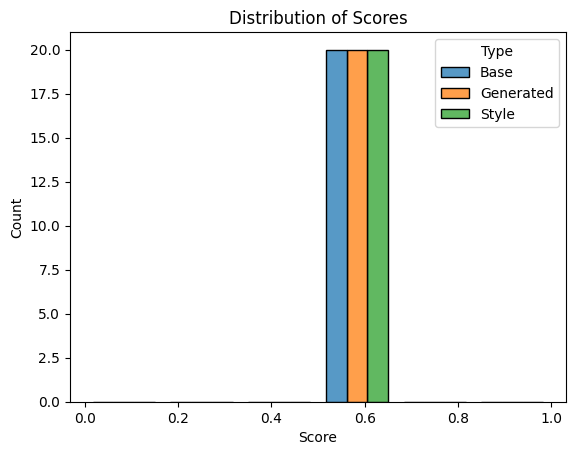

In [60]:
!pip install seaborn
import seaborn as sns
import pandas as pd

# Membuat DataFrame bersih untuk plotting
# Kita menggabungkan semua skor menjadi satu kolom panjang, dan memberi label jenisnya di kolom 'Type'
df = pd.DataFrame({
    'Score': [*base_scores, *generated_scores, *style_scores],
    'Type': ['Base']*len(base_scores) + ['Generated']*len(generated_scores) + ['Style']*len(style_scores)
})

# Plot dengan seaborn
# hue='Type': Memberi warna berbeda berdasarkan jenis teks
# multiple="dodge": Batang histogram tidak ditumpuk, tapi berdampingan
sns.histplot(data=df, x='Score', hue='Type', multiple="dodge", bins=6, shrink=.8)

plt.title('Distribution of Scores') # Judul grafik
plt.show()

Gunakan pengamatan ini untuk meningkatkan model Anda. Ingatlah bahwa LLM juri tidak sempurna, dan Anda dapat mencoba meningkatkan LLM juri untuk mengevaluasi output model dengan lebih baik. LLM juri yang lebih baik akan memberikan evaluasi yang lebih baik tentang seberapa baik kinerja model Yoda Anda, dan evaluasi yang lebih baik itu akan membantu Anda meningkatkan model Yoda Anda.

## 2.5: Kesimpulan

Bereksperimenlah dengan model obrolan dan LLM juri Anda untuk mencoba meningkatkan kualitas bicara ala Yoda. Kompetisi untuk lab ini akan didasarkan pada kriteria berikut:
* **Likelihood (Kemungkinan) bicara ala Yoda asli di bawah model obrolan Anda**: semakin baik model obrolan Anda memahami gaya bicara Yoda, ia akan memperkirakan *cross entropy loss* yang lebih rendah untuk bahasa yang merupakan gaya Yoda asli. Pada akhir lab ini, Anda akan mengevaluasi *likelihood* dari sampel uji *held-out* (data yang disimpan/tidak dilihat saat latihan) dari gaya Yoda asli menggunakan model obrolan Anda. Sertakan *likelihood* ini dalam laporan Anda. Ini memberi kita ukuran kuantitatif untuk membandingkan model obrolan yang berbeda (yang mungkin telah berinteraksi dengan LLM juri yang berbeda).
* **Eksperimen dan perubahan yang Anda coba untuk meningkatkan model obrolan Anda**: sertakan deskripsi perubahan yang Anda buat dan hasil yang Anda amati.

#### PENTING: JALANKAN CELL BERIKUT DI BAWAH INI UNTUK MENCETAK HASILNYA TETAPI JANGAN UBAH ISINYA.

In [61]:
# JANGAN UBAH/MODIFIKASI CELL INI.
# EKSEKUSI SEBELUM MENGIRIMKAN ENTRI/TUGAS ANDA KE LAB.

yoda_test_text = mdl.lab3.yoda_test_text
# Penjelasan: Mengambil teks rahasia (test set) yang disediakan oleh modul lab.

tokens = tokenizer(yoda_test_text, return_tensors="pt").to(model.device)
# Penjelasan: Mengubah teks rahasia tadi menjadi token angka.

# Dapatkan loglikelihood dari model
with torch.no_grad():
    outputs = model(**tokens)
    
    # Logika Shifting (Sama seperti saat training 1.3.3)
    logits = outputs.logits[:, :-1]  # Prediksi model (buang token terakhir)
    targets = tokens.input_ids[:, 1:] # Kunci jawaban (buang token pertama)
    
    # Menghitung seberapa akurat prediksi model terhadap kunci jawaban
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                           targets.reshape(-1))

print(f"Yoda test loglikelihood: {loss.item():.2f}")
# Penjelasan:
# - Angka yang keluar di sini adalah skor akhirmu.
# - Semakin KECIL angkanya, semakin BAGUS modelmu meniru Yoda.

Yoda test loglikelihood: 2.80
